In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Funciones auxiliares
def leer_archivo_txt(nombre_archivo, saltar_lineas=5, delimitador=';'):
    try:
        df = pd.read_csv(nombre_archivo, delimiter=delimitador, skiprows=saltar_lineas)
        df.columns = df.columns.str.strip()
        df['Wave'] = pd.to_numeric(df['Wave'], errors='coerce')
        df['Sample'] = pd.to_numeric(df['Sample'], errors='coerce')
        df.dropna(inplace=True)
        return df
    except Exception as e:
        print(f"Error al leer el archivo: {e}")
        return None
    
def graficar_datos(df, columna_x, columna_y):
    
    plt.figure(figsize=(8, 5))
    plt.plot(df[columna_x], df[columna_y], marker='', linestyle='-')
    plt.xlabel(columna_x)
    plt.ylabel(columna_y)
    plt.title(f"Gráfica de {columna_y} vs {columna_x}")
    plt.grid()
    plt.show()


def graficar_multiples_dfs(lista_dfs, nombres, título, columna_x, columna_y):
    
    plt.figure(figsize=(8, 5))
    for df, nombre in zip(lista_dfs, nombres):
        if df is not None and columna_x in df.columns and columna_y in df.columns:
            plt.plot(df[columna_x], df[columna_y], marker='', linestyle='-', markersize=3, linewidth=0.8, label=nombre)
        else:
            print(f"Error: No se pudo graficar {nombre}, columnas no encontradas")
    plt.xlabel(columna_x)
    plt.ylabel(columna_y)
    plt.title(título)
    plt.legend()
    plt.minorticks_on()  # Habilitar las marcas menores
    plt.grid(which='both', linestyle='-', linewidth=0.5, alpha=0.7)
    # Ajustar los márgenes de manera manual
    plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9)
    plt.show()

import matplotlib.pyplot as plt

def graficar_multiples_dfs_suavizados(lista_dfs, nombres, título, columna_x, columna_y):
    plt.figure(figsize=(8, 5))
    
    for df, nombre in zip(lista_dfs, nombres):
        if df is not None and columna_x in df.columns and columna_y in df.columns:
            if len(df) > 32:  # Asegurar que hay suficientes datos
                df_filtrado = df.iloc[16:-16]  # Excluir los primeros y últimos 16 elementos
            else:
                df_filtrado = df  # Si el DF tiene menos de 32 filas, se grafica completo
            
            plt.plot(df_filtrado[columna_x], df_filtrado[columna_y], marker='', linestyle='-', markersize=3, linewidth=0.8, label=nombre)
        else:
            print(f"Error: No se pudo graficar {nombre}, columnas no encontradas")

    plt.xlabel(columna_x)
    plt.ylabel(columna_y)
    plt.title(título)
    plt.legend()
    plt.minorticks_on()
    plt.grid(which='both', linestyle='-', linewidth=0.5, alpha=0.7)
    plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9)
    plt.show()


In [3]:
#Leer archivos

UV1 = "../Spectra/20250321_First_test\Sulfato50_shot01_7324767SP.txt" 
UV2 = "../Spectra/20250321_First_test\Sulfato50_shot01_7324768SP.txt" 
VIS = "../Spectra/20250321_First_test\Sulfato50_shot01_7324769SP.txt" 
NIR = "../Spectra/20250321_First_test\Sulfato50_shot01_7324770SP.txt" 

datos_UV1 = leer_archivo_txt(UV1)
datos_UV2 = leer_archivo_txt(UV2)
datos_VIS = leer_archivo_txt(VIS)
datos_NIR = leer_archivo_txt(NIR)


In [4]:
#Declaración de los intervalos de solapamiento

wls_UV1 = datos_UV1['Wave']
wls_UV2 = datos_UV2['Wave']
wls_VIS = datos_VIS['Wave']
wls_NIR = datos_NIR['Wave']
i1 = (wls_UV2[1], wls_UV1[len(wls_UV1)-1])
i2 = (wls_VIS[1], wls_UV2[len(wls_UV2)-1])
i3 = (wls_NIR[1], wls_VIS[len(wls_VIS)-1])


In [5]:
#Aislamiento de los intervalos de solapamiento

datos_UV1_fil1 = datos_UV1[(datos_UV1['Wave'] >= i1[0]) & (datos_UV1['Wave'] <= i1[1])]
datos_UV2_fil1 = datos_UV2[(datos_UV2['Wave'] >= i1[0]) & (datos_UV2['Wave'] <= i1[1])]

datos_UV2_fil2 = datos_UV2[(datos_UV2['Wave'] >= i2[0]) & (datos_UV2['Wave'] <= i2[1])]
datos_VIS_fil2 = datos_VIS[(datos_VIS['Wave'] >= i2[0]) & (datos_VIS['Wave'] <= i2[1])]

datos_VIS_fil3 = datos_VIS[(datos_VIS['Wave'] >= i3[0]) & (datos_VIS['Wave'] <= i3[1])]
datos_NIR_fil3 = datos_NIR[(datos_NIR['Wave'] >= i3[0]) & (datos_NIR['Wave'] <= i3[1])]

In [6]:
#Extracción de las medianas

mediana_UV1_fil1 = datos_UV1_fil1['Sample'].median()
mediana_UV2_fil1 = datos_UV2_fil1['Sample'].median()

mediana_UV2_fil2 = datos_UV2_fil2['Sample'].median()
mediana_VIS_fil2 = datos_VIS_fil2['Sample'].median()

mediana_VIS_fil3 = datos_VIS_fil3['Sample'].median()
mediana_NIR_fil3 = datos_NIR_fil3['Sample'].median()


In [7]:
#Cálculo de los coeficientes

coef1 = mediana_UV1_fil1/mediana_UV2_fil1
coef2 = mediana_UV2_fil2/mediana_VIS_fil2
coef3 = mediana_VIS_fil3/mediana_NIR_fil3

coef3

np.float64(1.609017175572519)

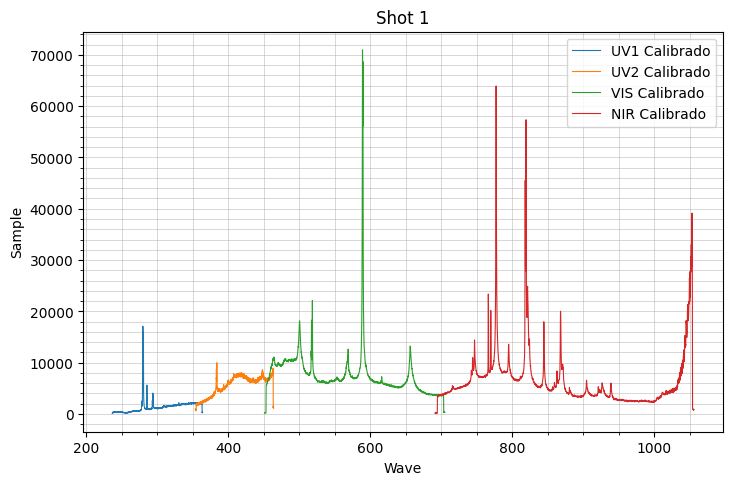

In [8]:
#Corrección del offset

datos_UV1_corr = datos_UV1.copy()
datos_UV2_corr = datos_UV2.copy()
datos_VIS_corr = datos_VIS.copy()
datos_NIR_corr = datos_NIR.copy()

datos_UV1_corr['Sample'] = datos_UV1_corr['Sample']
datos_UV2_corr['Sample'] = datos_UV2_corr['Sample']*coef1
datos_VIS_corr['Sample'] = datos_VIS_corr['Sample']*coef2*coef1
datos_NIR_corr['Sample'] = datos_NIR_corr['Sample']*coef3*coef2*coef1



dfs_calibrados = [datos_UV1_corr, datos_UV2_corr, datos_VIS_corr, datos_NIR_corr]
nombres_calibrados = ["UV1 Calibrado", "UV2 Calibrado", "VIS Calibrado", "NIR Calibrado"]
graficar_multiples_dfs(dfs_calibrados, nombres_calibrados, "Shot 1", 'Wave', 'Sample')



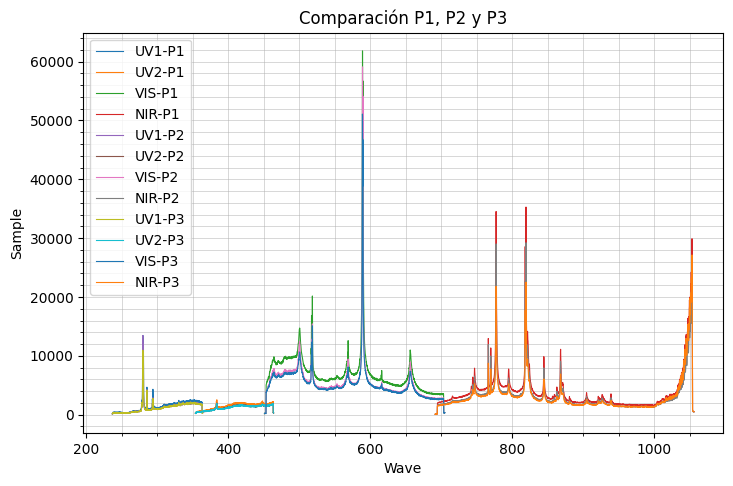

In [10]:
# Comparación de las tres posiciones
#De la posición 1 tomo el N2
#De la posición 2 tomo el N1
#De la posición 3 tomo el N1

UV1_P1 = "../Spectra/20250321_First_test\Sulfato50_Burst5-n2_7324767SP.txt"
UV2_P1 = "../Spectra/20250321_First_test\Sulfato50_Burst5-n2_7324768SP.txt" 
VIS_P1 = "../Spectra/20250321_First_test\Sulfato50_Burst5-n2_7324769SP.txt" 
NIR_P1 = "../Spectra/20250321_First_test\Sulfato50_Burst5-n2_7324770SP.txt" 
UV1_P2 = "../Spectra/20250321_First_test\Sulfato50_position2_Burst5-n1_7324767SP.txt"
UV2_P2 = "../Spectra/20250321_First_test\Sulfato50_position2_Burst5-n1_7324768SP.txt" 
VIS_P2 = "../Spectra/20250321_First_test\Sulfato50_position2_Burst5-n1_7324769SP.txt" 
NIR_P2 = "../Spectra/20250321_First_test\Sulfato50_position2_Burst5-n1_7324770SP.txt"
UV1_P3 = "../Spectra/20250321_First_test\Sulfato50_position3_Burst5-n1_7324767SP.txt"
UV2_P3 = "../Spectra/20250321_First_test\Sulfato50_position3_Burst5-n1_7324768SP.txt" 
VIS_P3 = "../Spectra/20250321_First_test\Sulfato50_position3_Burst5-n1_7324769SP.txt" 
NIR_P3 = "../Spectra/20250321_First_test\Sulfato50_position3_Burst5-n1_7324770SP.txt"


datos_UV1_P1 = leer_archivo_txt(UV1_P1)
datos_UV2_P1 = leer_archivo_txt(UV2_P1)
datos_VIS_P1 = leer_archivo_txt(VIS_P1)
datos_NIR_P1 = leer_archivo_txt(NIR_P1)
datos_UV1_P2 = leer_archivo_txt(UV1_P2)
datos_UV2_P2 = leer_archivo_txt(UV2_P2)
datos_VIS_P2 = leer_archivo_txt(VIS_P2)
datos_NIR_P2 = leer_archivo_txt(NIR_P2)
datos_UV1_P3 = leer_archivo_txt(UV1_P3)
datos_UV2_P3 = leer_archivo_txt(UV2_P3)
datos_VIS_P3 = leer_archivo_txt(VIS_P3)
datos_NIR_P3 = leer_archivo_txt(NIR_P3)


dfs1 = [datos_UV1_P1, datos_UV2_P1, datos_VIS_P1, datos_NIR_P1, datos_UV1_P2, datos_UV2_P2, datos_VIS_P2, datos_NIR_P2, datos_UV1_P3, datos_UV2_P3, datos_VIS_P3, datos_NIR_P3 ]
nombres1 = ["UV1-P1", "UV2-P1", "VIS-P1", "NIR-P1","UV1-P2", "UV2-P2", "VIS-P2", "NIR-P2","UV1-P3", "UV2-P3", "VIS-P3", "NIR-P3" ]
graficar_multiples_dfs(dfs1, nombres1, "Comparación P1, P2 y P3", 'Wave', 'Sample')



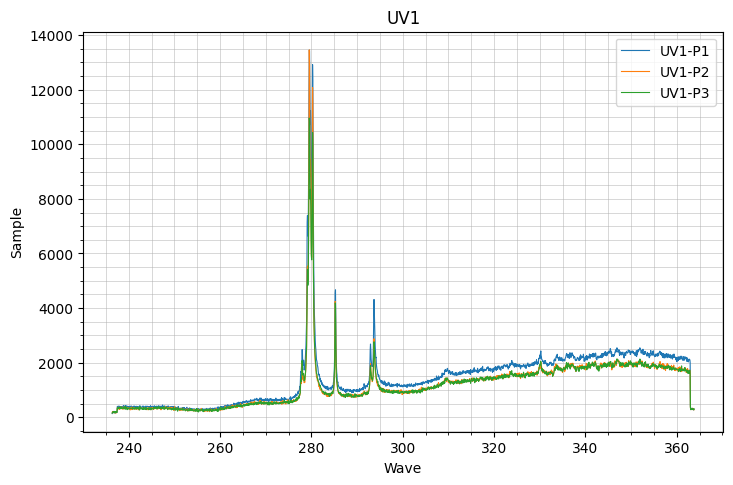

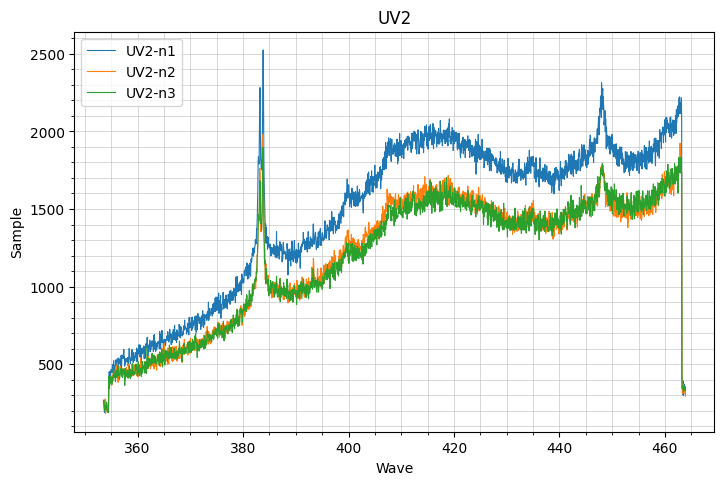

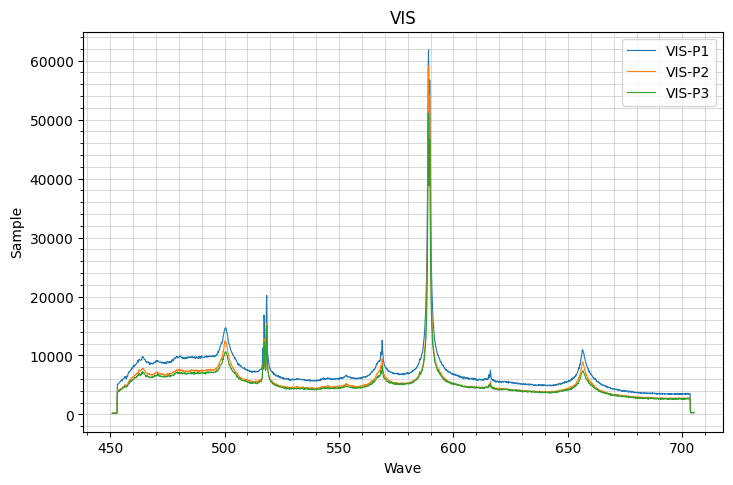

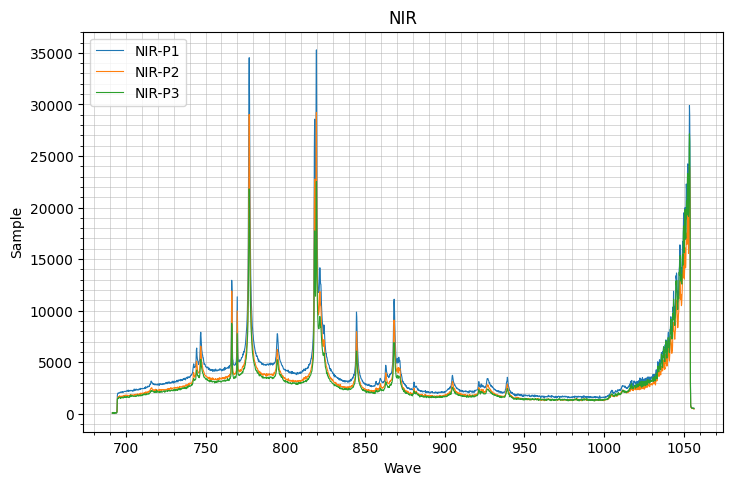

In [25]:
dfs_UV1 = [datos_UV1_P1, datos_UV1_P2, datos_UV1_P3]
nombres_UV1 = ["UV1-P1", "UV1-P2", "UV1-P3"]
espectro_UV1 = datos_UV1_P1['Sample'].values
graficar_multiples_dfs(dfs_UV1, nombres_UV1, "UV1", 'Wave', 'Sample')

dfs_UV2 = [datos_UV2_P1, datos_UV2_P2, datos_UV2_P3]
nombres_UV2 = ["UV2-n1", "UV2-n2", "UV2-n3"]
graficar_multiples_dfs(dfs_UV2, nombres_UV2, "UV2", 'Wave', 'Sample')

dfs_VIS = [datos_VIS_P1, datos_VIS_P2, datos_VIS_P3]
nombres_VIS = ["VIS-P1", "VIS-P2", "VIS-P3"]
graficar_multiples_dfs(dfs_VIS, nombres_VIS, "VIS", 'Wave', 'Sample')

dfs_NIR = [datos_NIR_P1, datos_NIR_P2, datos_NIR_P3]
nombres_NIR = ["NIR-P1", "NIR-P2", "NIR-P3"]
graficar_multiples_dfs(dfs_NIR, nombres_NIR, "NIR", 'Wave', 'Sample')

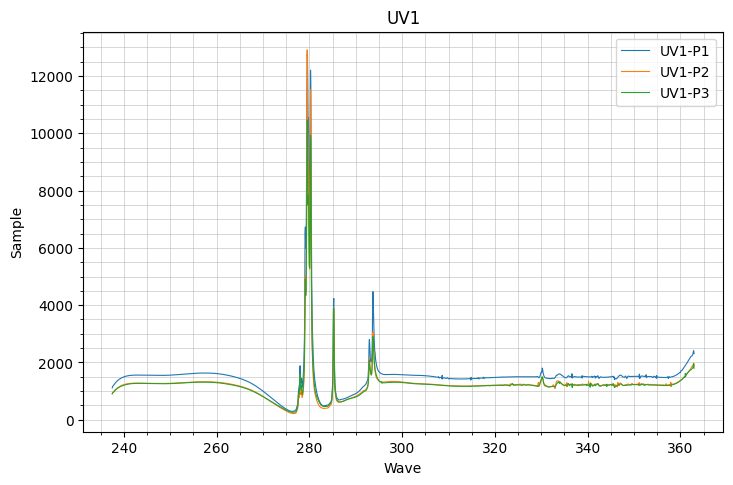

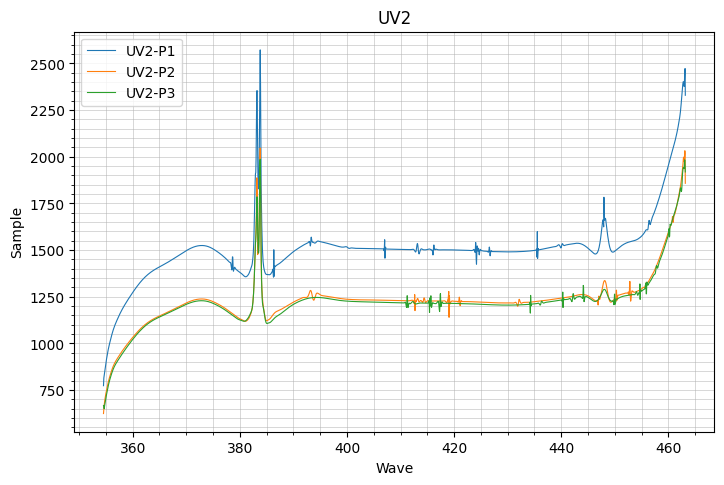

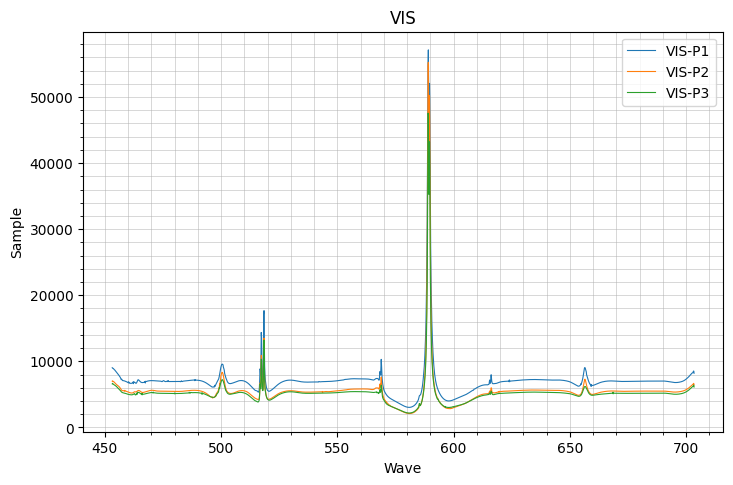

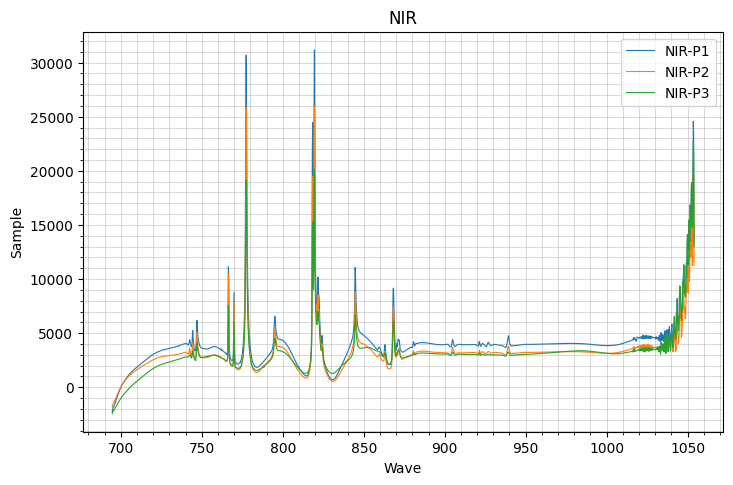

In [34]:
from denoising_fun import denoise_spectrum_uwt 
# Graficado suavizado


espectro_UV1_P1 = datos_UV1_P1['Sample'].values
espectro_UV1_P1_sr = denoise_spectrum_uwt(espectro_UV1_P1)
datos_UV1_P1['Sample'] = espectro_UV1_P1_sr
espectro_UV1_P2 = datos_UV1_P2['Sample'].values
espectro_UV1_P2_sr = denoise_spectrum_uwt(espectro_UV1_P2)
datos_UV1_P2['Sample'] = espectro_UV1_P2_sr
espectro_UV1_P3 = datos_UV1_P3['Sample'].values
espectro_UV1_P3_sr = denoise_spectrum_uwt(espectro_UV1_P3)
datos_UV1_P3['Sample'] = espectro_UV1_P3_sr
dfs_UV1_suavizados = [datos_UV1_P1, datos_UV1_P2, datos_UV1_P3]
nombres_UV1 = ["UV1-P1", "UV1-P2", "UV1-P3"]
graficar_multiples_dfs_suavizados(dfs_UV1_suavizados, nombres_UV1, "UV1", 'Wave', 'Sample')

espectro_UV2_P1 = datos_UV2_P1['Sample'].values
espectro_UV2_P1_sr = denoise_spectrum_uwt(espectro_UV2_P1)
datos_UV2_P1['Sample'] = espectro_UV2_P1_sr
espectro_UV2_P2 = datos_UV2_P2['Sample'].values
espectro_UV2_P2_sr = denoise_spectrum_uwt(espectro_UV2_P2)
datos_UV2_P2['Sample'] = espectro_UV2_P2_sr
espectro_UV2_P3 = datos_UV2_P3['Sample'].values
espectro_UV2_P3_sr = denoise_spectrum_uwt(espectro_UV2_P3)
datos_UV2_P3['Sample'] = espectro_UV2_P3_sr
dfs_UV2_suavizados = [datos_UV2_P1, datos_UV2_P2, datos_UV2_P3]
nombres_UV2 = ["UV2-P1", "UV2-P2", "UV2-P3"]
graficar_multiples_dfs_suavizados(dfs_UV2_suavizados, nombres_UV2, "UV2", 'Wave', 'Sample')

espectro_VIS_P1 = datos_VIS_P1['Sample'].values
espectro_VIS_P1_sr = denoise_spectrum_uwt(espectro_VIS_P1)
datos_VIS_P1['Sample'] = espectro_VIS_P1_sr
espectro_VIS_P2 = datos_VIS_P2['Sample'].values
espectro_VIS_P2_sr = denoise_spectrum_uwt(espectro_VIS_P2)
datos_VIS_P2['Sample'] = espectro_VIS_P2_sr
espectro_VIS_P3 = datos_VIS_P3['Sample'].values
espectro_VIS_P3_sr = denoise_spectrum_uwt(espectro_VIS_P3)
datos_VIS_P3['Sample'] = espectro_VIS_P3_sr
dfs_VIS_suavizados = [datos_VIS_P1, datos_VIS_P2, datos_VIS_P3]
nombres_VIS = ["VIS-P1", "VIS-P2", "VIS-P3"]
graficar_multiples_dfs_suavizados(dfs_VIS_suavizados, nombres_VIS, "VIS", 'Wave', 'Sample')

espectro_NIR_P1 = datos_NIR_P1['Sample'].values
espectro_NIR_P1_sr = denoise_spectrum_uwt(espectro_NIR_P1)
datos_NIR_P1['Sample'] = espectro_NIR_P1_sr
espectro_NIR_P2 = datos_NIR_P2['Sample'].values
espectro_NIR_P2_sr = denoise_spectrum_uwt(espectro_NIR_P2)
datos_NIR_P2['Sample'] = espectro_NIR_P2_sr
espectro_NIR_P3 = datos_NIR_P3['Sample'].values
espectro_NIR_P3_sr = denoise_spectrum_uwt(espectro_NIR_P3)
datos_NIR_P3['Sample'] = espectro_NIR_P3_sr
dfs_NIR_suavizados = [datos_NIR_P1, datos_NIR_P2, datos_NIR_P3]
nombres_NIR = ["NIR-P1", "NIR-P2", "NIR-P3"]
graficar_multiples_dfs_suavizados(dfs_NIR_suavizados, nombres_NIR, "NIR", 'Wave', 'Sample')